###Fundação Getulio Vargas
###Escola de Relações Internacionais
###Advanced Learning - 2026.1
###Prof.: Ronan Cunha
###Alunas: Maria Isadora Camargo Davida (C368703) e Rafaela Vianna (C373593)
###Entrega Final: Modelos de previsão de atraso de voos



# Funções

## Imports

In [1]:
import pandas as pd
import numpy as np
import json
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import (
    IsolationForest, RandomForestClassifier,
    HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder
import joblib
from imblearn.under_sampling import RandomUnderSampler
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

---
## Data Understanding

In [2]:
def avaliar_qualidade_dataframe(df: pd.DataFrame) -> None:
    if not isinstance(df, pd.DataFrame):
        print('Erro: O objeto fornecido não é um DataFrame do Pandas.')
        return

    print('RELATÓRIO DE QUALIDADE DA BASE DE DADOS')
    print('=' * 50)

    print('\n1. VISÃO GERAL')
    print('-' * 20)
    num_linhas, num_colunas = df.shape
    print(f'Dimensões: {num_linhas} linhas x {num_colunas} colunas')

    total_ausentes = df.isnull().sum().sum()
    pct = (total_ausentes / df.size) * 100
    print(f'Valores Ausentes: {total_ausentes} células ({pct:.2f}%)')

    total_dup = df.duplicated().sum()
    print(f'Linhas Duplicadas: {total_dup} linhas ({total_dup/num_linhas*100:.2f}%)')

    uso = df.memory_usage(deep=False).sum()
    def fmt_mem(b):
        for u in ['B','KB','MB','GB','TB']:
            if abs(b) < 1024.0: return f'{b:3.1f} {u}'
            b /= 1024.0
    print(f'Uso de Memória: {fmt_mem(uso)}')

    print('\n2. ANÁLISE POR COLUNA')
    print('-' * 20)
    rows = []
    for col in df.columns:
        aus = df[col].isnull().sum()
        rows.append({'Coluna': col, 'Tipo de Dado': df[col].dtype,
                     'Ausentes': aus, '% Ausentes': f'{aus/num_linhas*100:.2f}%',
                     'Valores Únicos': df[col].nunique()})
    print(pd.DataFrame(rows).to_string(index=False))

    print('\n3. ESTATÍSTICAS DESCRITIVAS (COLUNAS NUMÉRICAS)')
    print('-' * 50)
    num = df.select_dtypes(include=np.number)
    print(num.describe().round(2) if not num.empty else 'Nenhuma coluna numérica encontrada.')

    print('\n4. ESTATÍSTICAS DESCRITIVAS (COLUNAS CATEGÓRICAS/OBJETO)')
    print('-' * 60)
    cat = df.select_dtypes(include=['object','category'])
    print(cat.describe() if not cat.empty else 'Nenhuma coluna categórica/objeto encontrada.')

    print('\n' + '=' * 50)
    print('FIM DO RELATÓRIO')

### Análise Exploratória

In [3]:
def plotar_eda(df: pd.DataFrame, target: str = None, top_n: int = 5, max_categorias: int = 20) -> None:
    sns.set_theme(style='whitegrid', palette='muted')
    df2 = df.copy()

    # Excluir colunas que serão removidas como leakage (ex: Situacao.Voo)
    leakage_eda = ['Situacao.Voo', 'Codigo.Justificativa', 'Chegada.Real',
                   'Chegada.Prevista', 'Numero.Voo', 'Codigo.Autorizacao']
    cols_cat = [
        c for c in df2.select_dtypes(include=['object', 'category']).columns
        if c != target and df2[c].nunique() <= max_categorias
        and c not in leakage_eda
    ]
    cols_num = [c for c in df2.select_dtypes(include=np.number).columns if c != target]
    cols_dt  = df2.select_dtypes(include=['datetime64', 'datetimetz']).columns.tolist()

    if not cols_dt:
        for col in df2.select_dtypes(include=['object', 'category']).columns:
            try:
                df2[col] = pd.to_datetime(df2[col], errors='raise')
                cols_dt.append(col)
                if col in cols_cat:
                    cols_cat.remove(col)
                break
            except Exception:
                pass

    print(f'EDA — {len(cols_cat)} categóricas (cardinalidade ≤ {max_categorias}) | '
          f'{len(cols_num)} numéricas | {len(cols_dt)} de data/hora')

    for col in cols_cat:
        contagem = df2[col].value_counts().head(top_n).reset_index()
        contagem.columns = [col, 'quantidade']
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(data=contagem, x=col, y='quantidade',
                    palette='rocket_r', edgecolor='white', linewidth=0.8, ax=ax)
        for bar in ax.patches:
            ax.annotate(
                f"{int(bar.get_height()):,}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9, color='#333333', fontweight='bold'
            )
        ax.set_title(f'Top {top_n} — {col}', fontsize=13, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Quantidade')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

    print('Boxplot de colunas numéricas ignorado — base bruta não contém numéricas relevantes.')

    if cols_dt:
        col_dt = cols_dt[0]
        mensal = df2.set_index(col_dt).resample('ME').size().reset_index(name='quantidade')
        fig, ax = plt.subplots(figsize=(12, 4))
        sns.lineplot(data=mensal, x=col_dt, y='quantidade', marker='o', color='steelblue', ax=ax)
        ax.set_title(f'Volume por Mês — {col_dt}', fontsize=13, fontweight='bold')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

---
## Data Preparation — Cleaning

In [4]:
def fit_cleaning_params(df_train: pd.DataFrame,
                        perc_missing: float = 0.3,
                        unique_threshold: int = 1) -> dict:

    params = {}

    pct_na = df_train.isnull().sum() / len(df_train)
    cols_drop_missing = pct_na[pct_na > perc_missing].index.tolist()
    params['cols_drop_missing'] = cols_drop_missing

    df_tmp = df_train.drop(columns=cols_drop_missing, errors='ignore').copy()

    imputers = {}
    for col in df_tmp.columns:
        if pd.api.types.is_numeric_dtype(df_tmp[col]):
            imputers[col] = df_tmp[col].median()
        else:
            moda = df_tmp[col].mode(dropna=True)
            imputers[col] = moda.iloc[0] if not moda.empty else 'MISSING'

    params['imputers'] = imputers

    cols_constant = [c for c in df_tmp.columns if df_tmp[c].nunique(dropna=False) <= unique_threshold]
    params['cols_constant'] = cols_constant

    return params


def apply_cleaning(df: pd.DataFrame, params: dict) -> pd.DataFrame:

    df2 = df.copy()

    cols_drop_missing = [c for c in params['cols_drop_missing'] if c in df2.columns]
    df2.drop(columns=cols_drop_missing, inplace=True, errors='ignore')

    for col, valor in params['imputers'].items():
        if col in df2.columns:
            df2[col] = df2[col].fillna(valor)

    cols_constant = [c for c in params['cols_constant'] if c in df2.columns]
    df2.drop(columns=cols_constant, inplace=True, errors='ignore')

    return df2.reset_index(drop=True)


def clean_train_test(df_train: pd.DataFrame,
                     df_test: pd.DataFrame,
                     perc_missing: float = 0.3,
                     unique_threshold: int = 1):

    print('Iniciando limpeza consistente entre treino e teste...')

    df_train = df_train.drop_duplicates().reset_index(drop=True)
    df_test = df_test.drop_duplicates().reset_index(drop=True)

    params = fit_cleaning_params(
        df_train,
        perc_missing=perc_missing,
        unique_threshold=unique_threshold
    )

    df_train = apply_cleaning(df_train, params)
    df_test = apply_cleaning(df_test, params)

    print('Limpeza concluída!')
    return df_train, df_test

In [5]:
def outlier_correction(
    df: pd.DataFrame,
    sample_size: int = 50_000,
    contamination: float = 0.05,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Detecta outliers com IsolationForest usando apenas colunas numéricas.
    Treina em uma amostra para reduzir custo computacional e aplica no conjunto completo.

    Retorna o dataframe sem os registros classificados como outliers.
    """
    print('Beginning outlier detection with Isolation Forest...')

    df2 = df.copy()
    cols_num = df2.select_dtypes(include=np.number).columns.tolist()

    if not cols_num:
        print('Nenhuma coluna numérica encontrada. Etapa ignorada.')
        return df2

    n_sample = min(sample_size, len(df2))
    print(f'Treinando Isolation Forest em amostra de {n_sample:,} linhas (de {len(df2):,} totais)...')

    sample = df2[cols_num].sample(n=n_sample, random_state=random_state)

    iso = IsolationForest(
        random_state=random_state,
        n_jobs=-1,
        contamination=contamination
    )

    iso.fit(sample)
    pred = iso.predict(df2[cols_num])

    n_out = (pred == -1).sum()
    print(f'Total de observações: {len(df2):,}')
    print(f'Número de outliers detectados: {n_out:,}')
    print(f'Percentual de outliers removidos: {n_out / len(df2):.2%}')
    print('Outlier removal complete.')

    return df2[pred == 1].copy().reset_index(drop=True)

## Data Preparation — Treatment

### Estatísticas Descritivas — Base Tratada

In [6]:
def estatisticas_pos_tratamento(df: pd.DataFrame, target: str) -> None:
    """
    Exibe estatísticas descritivas da base APÓS limpeza e tratamento,
    atendendo ao requisito III do trabalho (Data Preparation).
    """
    sns.set_theme(style='whitegrid', palette='muted')
    print('=' * 55)
    print('ESTATÍSTICAS DESCRITIVAS — BASE TRATADA')
    print('=' * 55)
    print(f'\nDimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
    print(f'\nDistribuição do target ({target}):')
    vc = df[target].value_counts()
    vcp = df[target].value_counts(normalize=True).round(3) * 100
    for cls in vc.index:
        print(f'  Classe {cls}: {vc[cls]:,} ({vcp[cls]:.1f}%)')
    num = df.select_dtypes(include=np.number).drop(columns=[target], errors='ignore')
    if not num.empty:
        print('\nEstatísticas Descritivas — Variáveis Numéricas:')
        print(num.describe().round(3).to_string())
    cat = df.select_dtypes(include=['object', 'category'])
    if not cat.empty:
        print('\nEstatísticas Descritivas — Variáveis Categóricas:')
        print(cat.describe().to_string())
    print('\n' + '=' * 55)
    fig, ax = plt.subplots(figsize=(6, 4))
    cores = ['#4878CF', '#D65F5F']
    bars = ax.bar(
        [str(c) for c in vc.index], vc.values,
        color=cores[:len(vc)], edgecolor='white', linewidth=0.8
    )
    for bar in bars:
        ax.annotate(
            f'{int(bar.get_height()):,}',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
    ax.set_title(f'Distribuição do Target: {target}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Classe')
    ax.set_ylabel('Quantidade')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()

In [7]:
# ALTERAÇÃO 3 — correção de data off-by-one adicionada a criar_variavel_target

def criar_variavel_target(df: pd.DataFrame, target_col: str = 'Atraso') -> pd.DataFrame:
    """
    Cria o target binário: 1 = atrasado (>15 min), 0 = no prazo.
    Calcula a diferença entre Partida.Real e Partida.Prevista.

    Inclui correção de data off-by-one: registros onde a partida_real foi
    gravada com a data 1 dia antes do correto (erro de entrada de dados
    identificado na base ANAC) têm a data corrigida antes do cálculo.
    Registros com erro irrecuperável (>2 dias ou >10.000 min) são removidos.
    """
    df2 = df.copy()
    for col in ['Partida.Prevista', 'Partida.Real']:
        if col not in df2.columns:
            raise ValueError(f"Coluna necessária ausente: '{col}'")
        df2[col] = pd.to_datetime(df2[col], errors='coerce')

    # correção de data off-by-one
    atraso_raw = (df2['Partida.Real'] - df2['Partida.Prevista']).dt.total_seconds() / 60
    mask_neg_1d = (atraso_raw >= -1440) & (atraso_raw < -120)
    df2.loc[mask_neg_1d, 'Partida.Real'] += pd.Timedelta(days=1)

    # recalcula depois da correção
    atraso_raw = (df2['Partida.Real'] - df2['Partida.Prevista']).dt.total_seconds() / 60
    mask_invalido = (atraso_raw < -1440) | (atraso_raw > 10000)

    df2 = df2[~mask_invalido].copy().reset_index(drop=True)

    print(f'  Correção de data: {mask_neg_1d.sum()} registros corrigidos, '
          f'{mask_invalido.sum()} irrecuperáveis removidos.')

    atraso_min = (df2['Partida.Real'] - df2['Partida.Prevista']).dt.total_seconds() / 60
    df2[target_col] = (atraso_min > 15).astype(int)

    print(f"Target '{target_col}' criado: 1 = atrasado (>15 min), 0 = no prazo.")
    print(f"  Distribuição:\n{df2[target_col].value_counts(normalize=True).round(3)}")
    return df2


def criar_features_temporais(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    col_data = next((c for c in ['Partida.Prevista', 'Data.Hora.Partida.Prevista'] if c in df2.columns), None)
    if col_data is None:
        print('Aviso: coluna de data/hora não encontrada. Features temporais não criadas.')
        return df2

    df2[col_data] = pd.to_datetime(df2[col_data], errors='coerce')
    df2['hora_partida_prevista'] = df2[col_data].dt.hour
    df2['dia_semana'] = df2[col_data].dt.dayofweek
    df2['mes'] = df2[col_data].dt.month
    df2['fim_de_semana'] = (df2['dia_semana'] >= 5).astype(int)

    print(f"Features temporais criadas a partir de '{col_data}'.")
    return df2


def remover_colunas_data(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    cols_dt = df2.select_dtypes(include=['datetime64', 'datetimetz']).columns.tolist()
    if cols_dt:
        df2.drop(columns=cols_dt, inplace=True)
        print(f'Colunas datetime removidas: {cols_dt}')
    return df2


def ajustar_mapeamentos_treino(
    df_train: pd.DataFrame,
    target_col: str,
    max_categorias: int = 50,
    freq_cols: list = ['Origem', 'Destino'],
    one_hot_cols: list = ['Empresa']
) -> dict:
    """
    Aprende no treino:
    - frequências para Origem e Destino
    - categorias de Empresa para one-hot
    - mapeamentos das demais categóricas
    """
    mappings = {
        'freq_maps': {},
        'one_hot_levels': {},
        'label_maps': {},
        'high_cardinality_drop': []
    }

    # frequency encoding
    for col in freq_cols:
        if col in df_train.columns:
            mappings['freq_maps'][col] = df_train[col].value_counts(normalize=True).to_dict()

    # one-hot Empresa
    for col in one_hot_cols:
        if col in df_train.columns:
            mappings['one_hot_levels'][col] = sorted(df_train[col].astype(str).unique().tolist())

    # demais categóricas
    cols_cat = [c for c in df_train.select_dtypes(include=['object', 'category']).columns if c != target_col]
    cols_restantes = [c for c in cols_cat if c not in freq_cols + one_hot_cols]

    for col in cols_restantes:
        if df_train[col].nunique() > max_categorias:
            mappings['high_cardinality_drop'].append(col)
        else:
            categorias = sorted(df_train[col].astype(str).unique().tolist())
            mappings['label_maps'][col] = {cat: i for i, cat in enumerate(categorias)}

    return mappings


def aplicar_mapeamentos(
    df: pd.DataFrame,
    mappings: dict,
    target_col: str,
    colunas_treino: list = None
) -> pd.DataFrame:
    df2 = df.copy()

    # One-hot encoding para Empresa com base no treino
    for col, levels in mappings['one_hot_levels'].items():
        if col in df2.columns:
            serie = df2[col].astype(str)
            dummies = pd.get_dummies(serie, prefix=col, dtype=int)
            colunas_esperadas = [f'{col}_{nivel}' for nivel in levels]
            dummies = dummies.reindex(columns=colunas_esperadas, fill_value=0)
            df2 = pd.concat([df2.drop(columns=[col]), dummies], axis=1)
            print(f'One-hot encoding aplicado em: {col}')

    # Frequency encoding para Origem e Destino com mapa do treino
    for col, mapa in mappings['freq_maps'].items():
        if col in df2.columns:
            df2[col] = df2[col].map(mapa).fillna(0)
            print(f'Frequency encoding aplicado em: {col}')

    # Remover alta cardinalidade
    cols_drop = [c for c in mappings['high_cardinality_drop'] if c in df2.columns]
    if cols_drop:
        df2.drop(columns=cols_drop, inplace=True)
        print(f'Colunas removidas por alta cardinalidade: {cols_drop}')

    # Encoding das demais categóricas com base no treino
    cols_encoded = []
    for col, mapa in mappings['label_maps'].items():
        if col in df2.columns:
            df2[col] = df2[col].astype(str).map(mapa).fillna(-1).astype(int)
            cols_encoded.append(col)

    if cols_encoded:
        print(f'Encoding aplicado nas colunas: {cols_encoded}')

    # Garantir mesmas colunas do treino no teste
    if colunas_treino is not None:
        df2 = df2.reindex(columns=colunas_treino, fill_value=0)

    return df2


def preparar_base_inicial(df: pd.DataFrame, target_col: str = 'Atraso') -> pd.DataFrame:
    """
    Etapas seguras para qualquer base isoladamente.
    """
    df2 = df.copy()
    print('Iniciando o tratamento de dados...')
    df2 = criar_variavel_target(df2, target_col=target_col)
    df2 = criar_features_temporais(df2)
    df2 = remover_colunas_data(df2)
    return df2


def data_treatment_train_test(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    target_col: str = 'Atraso',
    max_categorias: int = 50
):
    """
    Trata treino e teste corretamente:
    - ajusta encoders no treino
    - aplica os mesmos encoders no teste
    """

    print('=== Tratamento do TREINO ===')
    df_train_base = preparar_base_inicial(df_train, target_col=target_col)

    print('\nAjustando mapeamentos no treino...')
    mappings = ajustar_mapeamentos_treino(
        df_train_base,
        target_col=target_col,
        max_categorias=max_categorias,
        freq_cols=['Origem', 'Destino'],
        one_hot_cols=['Empresa']
    )

    print('\nAplicando transformações no treino...')
    df_train_final = aplicar_mapeamentos(
        df_train_base,
        mappings,
        target_col=target_col
    )

    colunas_treino = df_train_final.columns.tolist()

    print('\n=== Tratamento do TESTE ===')
    df_test_base = preparar_base_inicial(df_test, target_col=target_col)

    print('\nAplicando transformações do treino no teste...')
    df_test_final = aplicar_mapeamentos(
        df_test_base,
        mappings,
        target_col=target_col,
        colunas_treino=colunas_treino
    )

    print('\nTratamento de treino e teste concluído com sucesso.')
    return df_train_final, df_test_final

---
## Modelagem

### Análise dos Resultados

In [8]:
def analisar_resultados(
    results: pd.DataFrame,
    trained_models: dict,
    y_test,
    x_test
) -> None:
    """
    Gera visualizações completas para análise dos modelos (IV — Análise dos Resultados):
      1. Gráfico comparativo de todas as métricas entre os modelos
      2. Matriz de confusão de cada modelo
      3. Curva ROC de todos os modelos sobrepostas
    """
    sns.set_theme(style='whitegrid', palette='muted')

    nomes = results.index.tolist()
    nomes_curtos = [n.replace('Classifier', '').replace('Regression', 'Reg') for n in nomes]

    # =========================
    # 1. Gráfico comparativo de métricas
    # =========================
    metricas = ['Accuracy', 'F1', 'AUC-ROC', 'Precision', 'Recall', 'CV F1 (média)', 'CV AUC (média)']
    x = np.arange(len(nomes))
    width = 0.11
    cores = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66', '#5BA35B', '#8B5E9E']

    fig, ax = plt.subplots(figsize=(13, 5))

    for i, (met, cor) in enumerate(zip(metricas, cores)):
        offset = (i - 3) * width
        bars = ax.bar(
            x + offset,
            results[met],
            width,
            label=met,
            color=cor,
            edgecolor='white',
            linewidth=0.6
        )

        for bar in bars:
            altura = bar.get_height()
            if pd.notna(altura):
                ax.annotate(
                    f'{altura:.3f}',
                    (bar.get_x() + bar.get_width() / 2, altura),
                    ha='center',
                    va='bottom',
                    fontsize=6.5,
                    rotation=90
                )

    ax.set_title('Comparativo de Métricas — Todos os Modelos', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(nomes_curtos, fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Score')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

    # =========================
    # 2. Matrizes de confusão
    # =========================
    n = len(nomes)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    if n == 1:
        axes = [axes]

    for ax, nome in zip(axes, nomes):
        model, _ = trained_models[nome]

        try:
            ConfusionMatrixDisplay.from_estimator(
                model,
                x_test,
                y_test,
                labels=[0, 1],
                display_labels=['No prazo', 'Atrasado'],
                ax=ax,
                colorbar=False,
                cmap='Blues'
            )

            ax.set_title(
                nome.replace('Classifier', '').replace('Regression', 'Reg'),
                fontsize=9,
                fontweight='bold'
            )

        except Exception as e:
            ax.set_title(
                nome.replace('Classifier', '').replace('Regression', 'Reg'),
                fontsize=9,
                fontweight='bold'
            )
            ax.text(
                0.5, 0.5,
                f'Erro ao gerar matriz\n{str(e)}',
                ha='center',
                va='center',
                wrap=True,
                fontsize=8
            )
            ax.axis('off')

    fig.suptitle('Matrizes de Confusão', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # =========================
    # 3. Curvas ROC
    # =========================
    fig, ax = plt.subplots(figsize=(8, 6))
    cores_roc = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66', '#5BA35B']

    for (nome, (model, _)), cor in zip(trained_models.items(), cores_roc):
        try:
            RocCurveDisplay.from_estimator(
                model,
                x_test,
                y_test,
                ax=ax,
                name=nome.replace('Classifier', '').replace('Regression', 'Reg'),
                color=cor
            )
        except Exception:
            pass

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.50)')
    ax.set_title('Curvas ROC — Comparativo dos Modelos', fontsize=13, fontweight='bold')
    ax.set_xlabel('Taxa de Falsos Positivos')
    ax.set_ylabel('Taxa de Verdadeiros Positivos')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

    # =========================
    # 4. Melhor modelo
    # =========================
    melhor = results['AUC-ROC'].idxmax()
    print(f'\n✅ Melhor modelo (maior AUC-ROC): {melhor}')
    print(f'   AUC-ROC: {results.loc[melhor, "AUC-ROC"]:.4f} | F1: {results.loc[melhor, "F1"]:.4f}')

In [9]:
def fnc_classification_and_save_models(df_train: pd.DataFrame, df_test: pd.DataFrame, target: str) -> pd.DataFrame:

    x_train = df_train.drop(columns=[target]).copy()
    y_train = df_train[target].copy()
    x_test  = df_test.drop(columns=[target]).copy()
    y_test  = df_test[target].copy()

    print('Divisão TEMPORAL: 2025 → treino | 2026 → teste')
    print(f'  Treino: {len(x_train):,} amostras | Teste: {len(x_test):,} amostras')

    x_train = x_train.astype(np.float32)
    x_test = x_test.astype(np.float32)

    # normalização para MLP
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)

    models = [
        LogisticRegression(max_iter=100, solver='saga', random_state=42, n_jobs=-1),
        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42, class_weight='balanced'),
        HistGradientBoostingClassifier(max_iter=100, random_state=42, class_weight='balanced'),
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42, early_stopping=True),
    ]

    names = [
        'LogisticRegression',
        'DecisionTreeClassifier',
        'RandomForestClassifier',
        'HistGradientBoostingClassifier',
        'MLPClassifier',
    ]

    acc_l, f1_l, auc_l, prec_l, rec_l, cv_f1_l, cv_auc_l = [], [], [], [], [], [], []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    trained_models = {}

    print('\nIniciando o treinamento dos modelos...')
    os.makedirs('models', exist_ok=True)

    for model, name in zip(models, names):
        print(f'\n- Treinando: {name}')

        x_tr = x_train_scaled if name == 'MLPClassifier' else x_train
        x_te = x_test_scaled if name == 'MLPClassifier' else x_test

        model.fit(x_tr, y_train)
        preds = model.predict(x_test_scaled if name == 'MLPClassifier' else x_test)

        cv_results = cross_validate(
            model, x_tr, y_train, cv=cv,
            scoring={'f1': 'f1_weighted', 'auc': 'roc_auc'},
            n_jobs=-1, return_train_score=False
        )

        cv_f1_mean = cv_results['test_f1'].mean()
        cv_f1_std  = cv_results['test_f1'].std()
        cv_auc_mean = cv_results['test_auc'].mean()
        cv_auc_std  = cv_results['test_auc'].std()

        cv_f1_l.append(cv_f1_mean)
        cv_auc_l.append(cv_auc_mean)

        acc  = accuracy_score(y_test, preds)
        f1   = f1_score(y_test, preds, average='weighted')
        prec = precision_score(y_test, preds, average='weighted', zero_division=0)
        rec  = recall_score(y_test, preds, average='weighted', zero_division=0)

        try:
            if hasattr(model, "predict_proba"):
                auc = roc_auc_score(y_test, model.predict_proba(x_te)[:, 1])
            elif hasattr(model, "decision_function"):
                auc = roc_auc_score(y_test, model.decision_function(x_te))
            else:
                auc = float('nan')
        except Exception:
            auc = float('nan')

        acc_l.append(acc)
        f1_l.append(f1)
        auc_l.append(auc)
        prec_l.append(prec)
        rec_l.append(rec)

        trained_models[name] = (model, preds)

        print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f} | AUC-ROC: {auc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f}')
        print(f'  CV (treino, 5-fold) — F1: {cv_f1_mean:.4f} ± {cv_f1_std:.4f} | AUC-ROC: {cv_auc_mean:.4f} ± {cv_auc_std:.4f}')
        print(f'\n  Relatório detalhado:\n{classification_report(y_test, preds, zero_division=0)}')

        fname = f'models/{name}_model.joblib'
        joblib.dump(model, fname)
        print(f"  Modelo salvo: '{fname}'")

    results = pd.DataFrame({
        'Accuracy': acc_l, 'F1': f1_l, 'AUC-ROC': auc_l,
        'Precision': prec_l, 'Recall': rec_l,
        'CV F1 (média)': cv_f1_l, 'CV AUC (média)': cv_auc_l
    }, index=names).sort_values(by='AUC-ROC', ascending=False)

    analisar_resultados(results, trained_models, y_test, x_test)

    print('\nAvaliação e salvamento de modelos concluídos.')
    return results

---
# Pipelines

In [10]:
def pipeline_treino(df: pd.DataFrame, target: str = 'Atraso', colunas_leakage: list = None) -> None:
    """
    Pipeline completo de treino:
      1. Data Understanding
         1.1 Relatório de qualidade (base bruta)
         1.2 Análise exploratória — EDA (base bruta)
      2. Data Preparation
         2.1 Remoção de colunas de leakage
         2.2 Data Cleaning
         2.3 Data Treatment
         2.4 Estatísticas descritivas (base tratada)
      3. Modeling
         3.1 Treino, avaliação e salvamento dos modelos
         3.2 Análise dos resultados + gráficos comparativos
      4. Salva metadados JSON
    """

    # ── Split temporal ──────────────────────────
    col_data = 'Partida.Prevista'
    ano = pd.to_datetime(df[col_data], errors='coerce').dt.year

    df_train_raw = df[ano == 2025].copy().reset_index(drop=True)
    df_test_raw  = df[ano == 2026].copy().reset_index(drop=True)

    print(f'Split temporal: treino={len(df_train_raw):,} (2025) | teste={len(df_test_raw):,} (2026)')

    # Data Understanding na base bruta de treino
    avaliar_qualidade_dataframe(df_train_raw)
    plotar_eda(df_train_raw, target=target)

    # ── Remoção de leakage ANTES da criação do target ─────────────────────
    if colunas_leakage:
        cols_antes_target = [c for c in colunas_leakage if c != 'Partida.Real']
        df_train_raw.drop(columns=cols_antes_target, errors='ignore', inplace=True)
        df_test_raw.drop(columns=cols_antes_target, errors='ignore', inplace=True)

    # ── Data Cleaning consistente entre treino e teste ────────────────────
    print('\n--- Limpeza consistente de treino e teste ---')

    df_train_clean, df_test_clean = clean_train_test(
        df_train_raw,
        df_test_raw,
        perc_missing=0.5, #antes era 0.3
        unique_threshold=1
    )

    # ── Data Treatment CORRETO: treino e teste juntos ─────────────────────
    print('\n--- Tratamento conjunto de treino e teste ---')

    df_train, df_test = data_treatment_train_test(
        df_train=df_train_clean,
        df_test=df_test_clean,
        target_col=target,
        max_categorias=50
    )

    # ── Remoção de Partida.Real DEPOIS da criação do target ───────────────
    if colunas_leakage and 'Partida.Real' in colunas_leakage:
        df_train.drop(columns=['Partida.Real'], errors='ignore', inplace=True)
        df_test.drop(columns=['Partida.Real'], errors='ignore', inplace=True)

    # ── Undersampling ────────────────────────────────────────
    from imblearn.under_sampling import RandomUnderSampler
    print('\nAplicando undersampling no treino...')
    print(f'Antes: {df_train[target].value_counts().to_dict()}')

    rus = RandomUnderSampler(sampling_strategy=0.5, random_state=42)
    X_res, y_res = rus.fit_resample(
        df_train.drop(columns=[target]),
        df_train[target]
    )
    df_train = pd.concat([X_res, y_res], axis=1).reset_index(drop=True)
    print(f'Depois: {df_train[target].value_counts().to_dict()}')

    # ── Outlier correction ────────────────────────────────────────────────
    print('\nAplicando outlier correction nas features numéricas do treino...')

    target_train_vals = df_train[target].copy()

    df_train_feats = df_train.drop(columns=[target])
    df_train_feats = outlier_correction(df_train_feats)

    df_train = df_train_feats.copy()
    df_train[target] = target_train_vals.loc[df_train_feats.index].values

    # ── Garantia final de colunas alinhadas ───────────────────────────────
    df_test = df_test.reindex(columns=df_train.columns, fill_value=0)

    print(f'Colunas alinhadas: {df_train.shape[1]} total')

    # ── Estatísticas e modelagem ──────────────────────────────────────────
    estatisticas_pos_tratamento(df_train, target=target)

    print("Colunas no treino:")
    print(df_train.columns.tolist())
    print(f"Shape treino: {df_train.shape}")

    results = fnc_classification_and_save_models(
        df_train,
        df_test,
        target
    )

    # ── Salvar metadados ─────────────────────────────────────────────────
    os.makedirs('models', exist_ok=True)

    infos = {
        'target': target,
        'x_vars': df_train.drop(columns=[target]).columns.tolist()
    }

    with open('models/model_infos.json', 'w') as f:
        json.dump(infos, f, indent=4)

    print('\nTreino dos modelos finalizado.')
    print('\nResumo dos resultados:')
    print(results.round(4))

---
# Aplicação

## Importação dos Dados

### ALTERAÇÃO 1 — leitura e renomeação de colunas da base ANAC

In [11]:
# ALTERAÇÃO 1 — carregamento da base ANAC com renomeação de colunas
df_flights = pd.read_csv('voos_clima.csv', low_memory=False)

df_flights = df_flights.rename(columns={
    'partida_prevista':   'Partida.Prevista',
    'partida_real':       'Partida.Real',
    'chegada_prevista':   'Chegada.Prevista',
    'chegada_real':       'Chegada.Real',
    'situacao_voo':       'Situacao.Voo',
    'justificativa':      'Codigo.Justificativa',
    'icao_empresa_aerea': 'Empresa',
    'numero_voo':         'Numero.Voo',
    'tipo_linha':         'Tipo.Linha',
    'icao_origem':        'Origem',
    'icao_destino':       'Destino',
    'codigo_autorizacao': 'Codigo.Autorizacao',
    # novas colunas de clima — não precisam renomear, já ficam com nomes bons
})

# ALTERAÇÃO 2 — manter só voos realizados com datas completas
df_flights = df_flights[df_flights['Situacao.Voo'] == 'REALIZADO'].copy()
df_flights = df_flights.dropna(subset=['Partida.Real', 'Partida.Prevista']).reset_index(drop=True)
print(f'Voos realizados com datas completas: {len(df_flights):,}')

# ALTERAÇÃO NOVA — remover colunas auxiliares do join com clima
df_flights = df_flights.drop(columns=[
    'municipio_origem_pad', 'municipio_destino_pad', 'partida_datetime',
    'municipio_origem', 'municipio_destino',
    'data', 'hora','estacao_inmet_origem', 'estacao_inmet_destino'
], errors='ignore')

df_flights.head()

Voos realizados com datas completas: 1,109,435


,Empresa,Numero.Voo,Codigo.Autorizacao,Tipo.Linha,Origem,Destino,Partida.Prevista,Partida.Real,Chegada.Prevista,Chegada.Real,...,taxa_atraso_empresa,taxa_atraso_hora,ocupacao_origem,precipitacao_origem,umidade_origem,precipitacao_destino,umidade_destino,atraso_voo_anterior,taxa_atraso_aeroporto,distancia_km
0,ACN,5100,9,N,SBKP,SBMI,2025-01-01 15:05:00,2025-01-01 15:10:00,2025-01-01 17:00:00,2025-01-01 17:02:00,...,0.189285,0.181718,6.0,NaN,NaN,NaN,NaN,NaN,0.167793,NaN
1,ACN,5100,9,N,SBKP,SBMI,2025-01-03 15:05:00,2025-01-03 16:28:00,2025-01-03 17:00:00,2025-01-03 18:13:00,...,0.189285,0.181718,6.0,NaN,NaN,NaN,NaN,NaN,0.167793,NaN
2,ACN,5100,9,N,SBKP,SBMI,2025-01-04 14:35:00,2025-01-04 15:20:00,2025-01-04 16:30:00,2025-01-04 17:13:00,...,0.189285,0.175071,8.0,NaN,NaN,NaN,NaN,83.0,0.167793,NaN
3,ACN,5100,9,N,SBKP,SBMI,2025-01-05 15:05:00,2025-01-05 15:05:00,2025-01-05 17:00:00,2025-01-05 16:47:00,...,0.189285,0.181718,5.0,NaN,NaN,NaN,NaN,45.0,0.167793,NaN
4,ACN,5100,9,N,SBKP,SBMI,2025-01-06 15:05:00,2025-01-06 14:59:00,2025-01-06 17:00:00,2025-01-06 16:52:00,...,0.189285,0.181718,9.0,NaN,NaN,NaN,NaN,0.0,0.167793,NaN


## Treinar os Modelos

In [12]:
# ALTERAÇÃO 2 — leakage atualizado para a base ANAC
# Chegada.Prevista: em produção não estaria disponível antes do voo
# Numero.Voo e Codigo.Autorizacao: identificadores sem valor preditivo
colunas_leakage = [
    'Partida.Real',
    'Chegada.Real',
    'Chegada.Prevista',
    'Situacao.Voo',
    'Codigo.Justificativa',
    'Numero.Voo',
    'Codigo.Autorizacao',
]

In [13]:
print(df_flights.columns.tolist())
print(df_flights.shape)

['Empresa', 'Numero.Voo', 'Codigo.Autorizacao', 'Tipo.Linha', 'Origem', 'Destino', 'Partida.Prevista', 'Partida.Real', 'Chegada.Prevista', 'Chegada.Real', 'Situacao.Voo', 'Codigo.Justificativa', 'taxa_atraso_rota', 'taxa_atraso_empresa', 'taxa_atraso_hora', 'ocupacao_origem', 'precipitacao_origem', 'umidade_origem', 'precipitacao_destino', 'umidade_destino', 'atraso_voo_anterior', 'taxa_atraso_aeroporto', 'distancia_km']
(1109435, 23)


Split temporal: treino=892,790 (2025) | teste=148,743 (2026)
RELATÓRIO DE QUALIDADE DA BASE DE DADOS

1. VISÃO GERAL
--------------------
Dimensões: 892790 linhas x 23 colunas
Valores Ausentes: 1913038 células (9.32%)
Linhas Duplicadas: 0 linhas (0.00%)
Uso de Memória: 156.7 MB

2. ANÁLISE POR COLUNA
--------------------
               Coluna Tipo de Dado  Ausentes % Ausentes  Valores Únicos
              Empresa       object         0      0.00%               9
           Numero.Voo       object         0      0.00%            6342
   Codigo.Autorizacao       object         0      0.00%               6
           Tipo.Linha       object         0      0.00%               5
               Origem       object         0      0.00%             238
              Destino       object         0      0.00%             235
     Partida.Prevista       object         0      0.00%          105766
         Partida.Real       object         0      0.00%          401955
     Chegada.Prevista       o

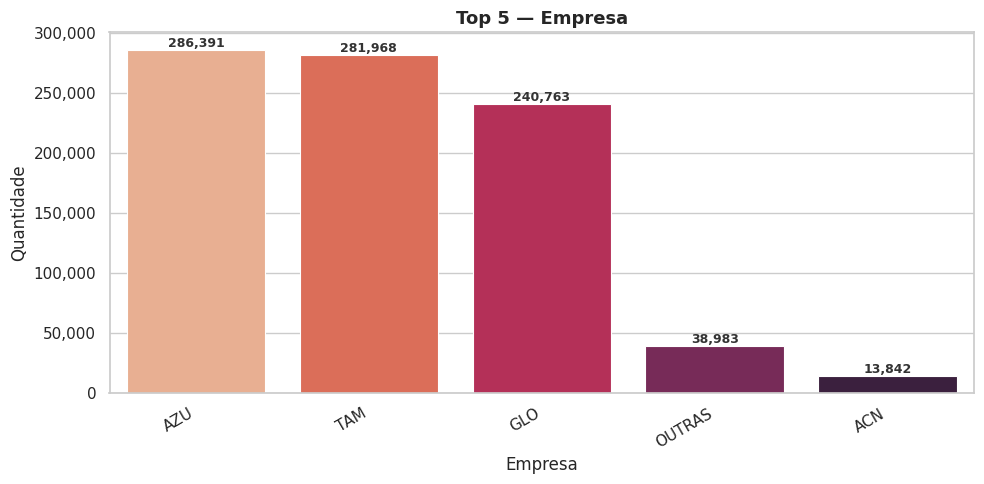

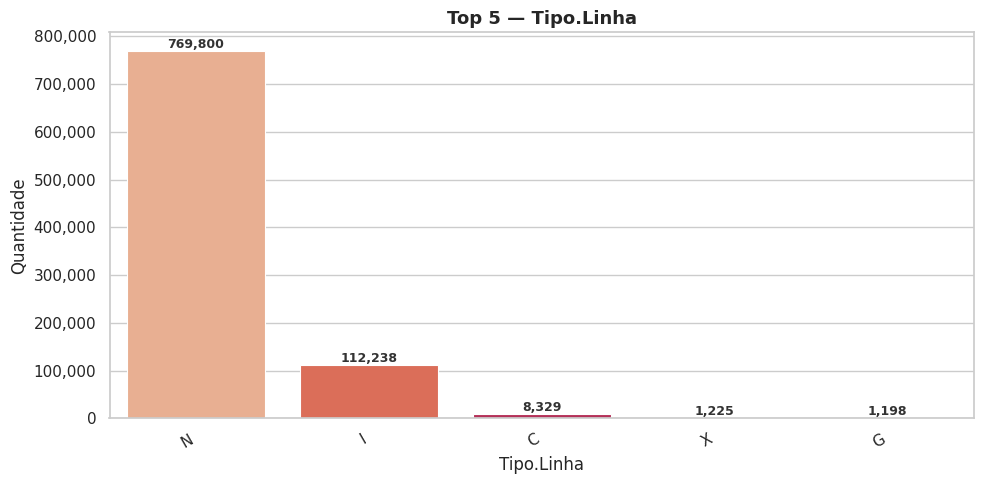

Boxplot de colunas numéricas ignorado — base bruta não contém numéricas relevantes.


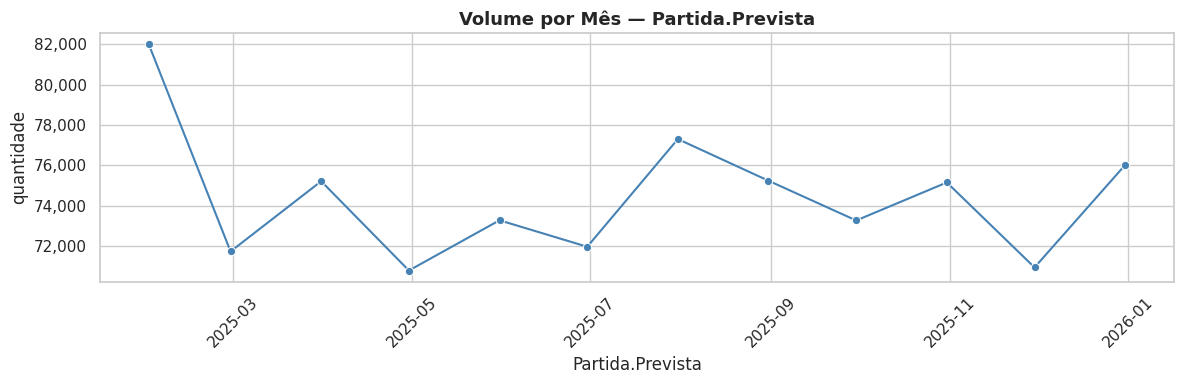


--- Limpeza consistente de treino e teste ---
Iniciando limpeza consistente entre treino e teste...
Limpeza concluída!

--- Tratamento conjunto de treino e teste ---
=== Tratamento do TREINO ===
Iniciando o tratamento de dados...
  Correção de data: 95 registros corrigidos, 5 irrecuperáveis removidos.
Target 'Atraso' criado: 1 = atrasado (>15 min), 0 = no prazo.
  Distribuição:
Atraso
0    0.84
1    0.16
Name: proportion, dtype: float64
Features temporais criadas a partir de 'Partida.Prevista'.
Colunas datetime removidas: ['Partida.Prevista', 'Partida.Real']

Ajustando mapeamentos no treino...

Aplicando transformações no treino...
One-hot encoding aplicado em: Empresa
Frequency encoding aplicado em: Origem
Frequency encoding aplicado em: Destino
Encoding aplicado nas colunas: ['Tipo.Linha']

=== Tratamento do TESTE ===
Iniciando o tratamento de dados...
  Correção de data: 35 registros corrigidos, 0 irrecuperáveis removidos.
Target 'Atraso' criado: 1 = atrasado (>15 min), 0 = no praz

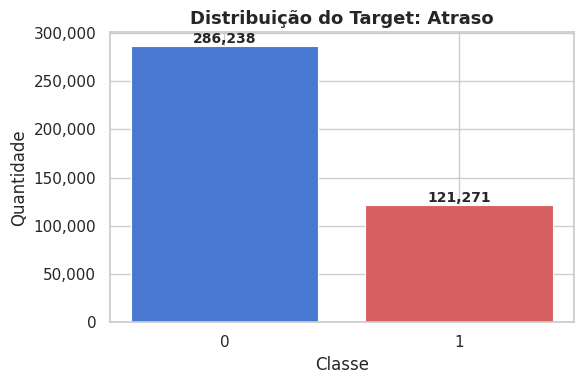

Colunas no treino:
['Tipo.Linha', 'Origem', 'Destino', 'taxa_atraso_rota', 'taxa_atraso_empresa', 'taxa_atraso_hora', 'ocupacao_origem', 'precipitacao_origem', 'umidade_origem', 'precipitacao_destino', 'umidade_destino', 'atraso_voo_anterior', 'taxa_atraso_aeroporto', 'distancia_km', 'hora_partida_prevista', 'dia_semana', 'mes', 'fim_de_semana', 'Empresa_ACN', 'Empresa_ARG', 'Empresa_AZU', 'Empresa_CMP', 'Empresa_GLO', 'Empresa_LAN', 'Empresa_OUTRAS', 'Empresa_TAM', 'Empresa_TAP', 'Atraso']
Shape treino: (407509, 28)
Divisão TEMPORAL: 2025 → treino | 2026 → teste
  Treino: 407,509 amostras | Teste: 148,743 amostras

Iniciando o treinamento dos modelos...

- Treinando: LogisticRegression
  Accuracy: 0.8226 | F1: 0.7546 | AUC-ROC: 0.6526 | Precision: 0.7412 | Recall: 0.8226
  CV (treino, 5-fold) — F1: 0.6117 ± 0.0007 | AUC-ROC: 0.6289 ± 0.0022

  Relatório detalhado:
              precision    recall  f1-score   support

           0       0.83      0.99      0.90    123097
           1 

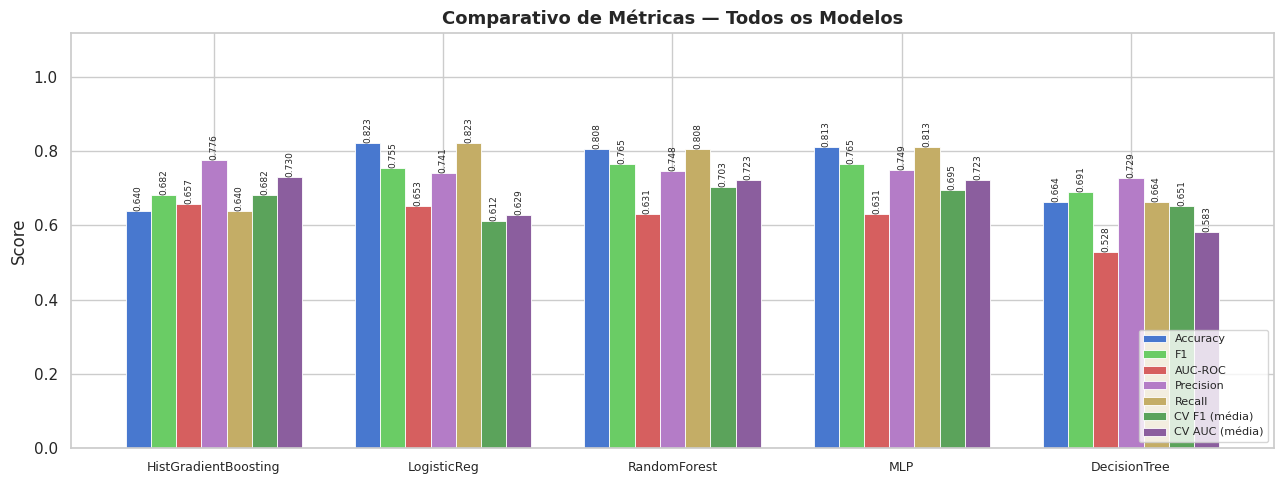

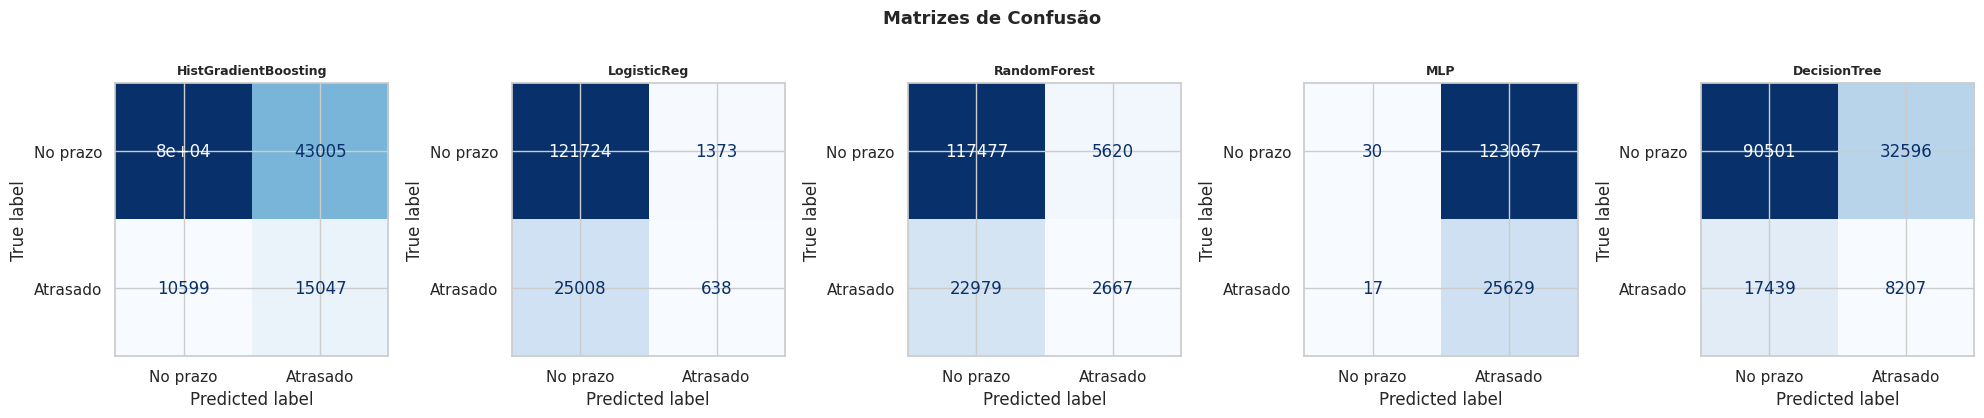

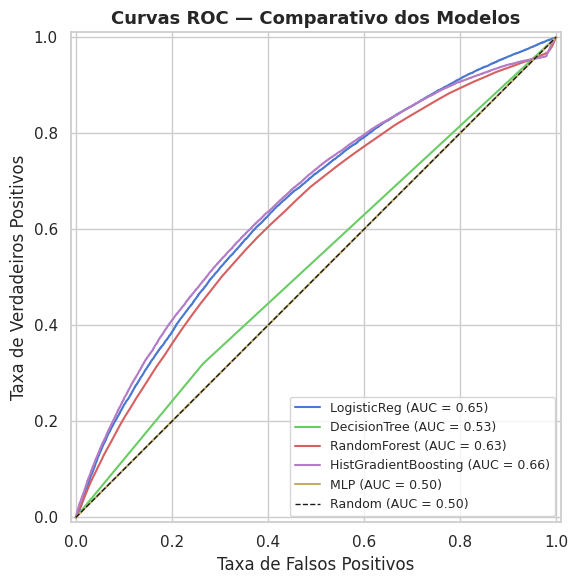


✅ Melhor modelo (maior AUC-ROC): HistGradientBoostingClassifier
   AUC-ROC: 0.6567 | F1: 0.6821

Avaliação e salvamento de modelos concluídos.

Treino dos modelos finalizado.

Resumo dos resultados:
                                Accuracy      F1  AUC-ROC  Precision  Recall  \
HistGradientBoostingClassifier    0.6396  0.6821   0.6567     0.7756  0.6396   
LogisticRegression                0.8226  0.7546   0.6526     0.7412  0.8226   
RandomForestClassifier            0.8077  0.7649   0.6312     0.7477  0.8077   
MLPClassifier                     0.8128  0.7647   0.6309     0.7493  0.8128   
DecisionTreeClassifier            0.6636  0.6909   0.5276     0.7286  0.6636   

                                CV F1 (média)  CV AUC (média)  
HistGradientBoostingClassifier         0.6822          0.7303  
LogisticRegression                     0.6117          0.6289  
RandomForestClassifier                 0.7034          0.7234  
MLPClassifier                          0.6954          0.7235  

In [14]:
pipeline_treino(df_flights, target='Atraso', colunas_leakage=colunas_leakage)

In [15]:
print(df_flights[['taxa_atraso_rota', 'taxa_atraso_empresa',
                   'taxa_atraso_hora', 'ocupacao_origem',
                   'precipitacao_origem', 'umidade_origem',
                   'precipitacao_destino', 'umidade_destino']].isnull().mean().round(3) * 100)

taxa_atraso_rota         0.0
taxa_atraso_empresa      0.0
taxa_atraso_hora         0.0
ocupacao_origem         14.5
precipitacao_origem     38.7
umidade_origem          35.3
precipitacao_destino    38.7
umidade_destino         35.3
dtype: float64
